# Week 6 Worksheet: Running OLS in Python

**ECC3479 — Data and Evidence in Economics**

This notebook covers bivariate and multiple OLS regression.
You will fit models, interpret coefficients, examine how controls
change estimates (OVB), and diagnose your final specification.

Work through each part in order. Save figures to `output/`.


In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

np.random.seed(20260407)
sns.set_theme(style="whitegrid", font_scale=1.1)

DATA_DIR   = Path("../data")
OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# Load the dataset
df = pd.read_csv(DATA_DIR / "wage_data.csv")
print(df.shape)
df.head()


(500, 6)


,worker_id,education,experience,female,industry,log_wage
0,1,11,21,0,Healthcare,3.2773
1,2,13,28,0,Finance,3.9201
2,3,15,24,1,Education,3.4982
3,4,12,24,1,Finance,3.4337
4,5,15,6,0,Services,2.8072


---
## Part A: Simple OLS

**Context.** The dataset `wage_data.csv` contains 500 Australian workers
from a 2022 HILDA-style survey. Variables:

| Column | Description |
|--------|-------------|
| `worker_id` | Worker identifier |
| `education` | Years of completed schooling (8–22) |
| `experience` | Years of work experience (0–40) |
| `female` | 1 = female, 0 = male |
| `industry` | Industry sector (5 categories) |
| `log_wage` | Log hourly wage (outcome) |


### Question 1

Run a bivariate OLS regression of `log_wage` on `education`.
Print the coefficient table.


In [3]:
# Q1 — bivariate OLS: log_wage ~ education
m1 = smf.ols("log_wage ~ education", data=df).fit()
print(m1.summary().tables[1])


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.5977      0.086     30.333      0.000       2.429       2.766
education      0.0642      0.006     10.832      0.000       0.053       0.076


### Question 2

Interpret the `education` coefficient precisely. Your answer should state:
- The direction and magnitude of the association
- The units of both the predictor and the outcome (log wage → approximate % change)
- A careful caveat about what this estimate *does not* tell us


In [4]:
# Q2 — Interpretation (written answer — no code needed)
# Sample answer:
# The coefficient on education is approximately 0.064.
# One additional year of schooling is associated with a 6.4% higher hourly wage
# on average (using the approximation that Δlog_wage ≈ % change).
# This is a CORRELATION, not a causal estimate: workers with more education
# may also differ on experience, ability, or family background, all of which
# independently affect wages. Without controlling for these confounders, we
# cannot interpret 0.064 as the causal return to schooling.
print(f"Education coefficient (simple): {m1.params['education']:.4f}")
print(f"R-squared: {m1.rsquared:.3f}")


Education coefficient (simple): 0.0642
R-squared: 0.191


### Question 3

What is the $R^2$ of the simple regression? Explain what it measures
and what it *does not* tell you about the usefulness of education as a
predictor of wages.


In [5]:
# Q3 — R-squared interpretation
print(f"R-squared: {m1.rsquared:.3f}")
# R^2 ≈ 0.19: education alone explains about 19% of the variation in log wages.
# This tells us that education is a moderate predictor of wages in this sample.
# It does NOT tell us whether the relationship is causal, nor whether the
# remaining 81% of variation is explainable by other variables.
# A high R^2 is neither necessary nor sufficient for a valid causal estimate.


R-squared: 0.191


---
## Part B: Multiple Regression and OVB

**Goal.** Add controls and observe how the `education` coefficient changes.
Use the direction of change to identify the sign of omitted variable bias.


### Question 4

Add `experience` as a control variable. Run the regression and compare
the `education` coefficient to Question 1. Does it rise or fall?

Using the OVB formula $\tilde{\beta}_1 = \hat{\beta}_1 + \hat{\beta}_2 \cdot \hat{\gamma}_1$,
determine the sign of the bias in the simple regression.


In [6]:
# Q4 — Add experience
m2 = smf.ols("log_wage ~ education + experience", data=df).fit()
print(m2.summary().tables[1])
print()
print(f"Simple regression:   education coeff = {m1.params['education']:.4f}")
print(f"With experience:     education coeff = {m2.params['education']:.4f}")
print(f"Change: {m2.params['education'] - m1.params['education']:+.4f}")
print()
# OVB analysis:
# beta_experience > 0 (more experience → higher wages)
# Cov(education, experience) < 0 (more education → started work later → less experience)
# so gamma_1 = Cov(educ, exp)/Var(educ) < 0
# OVB = beta_experience * gamma_1 = (positive) * (negative) = NEGATIVE (downward bias)
# => simple regression UNDERSTATES the true return to education
# Confirming: coefficient rises when we add experience (from ~0.064 to ~0.080)
gamma1 = df["education"].cov(df["experience"]) / df["education"].var()
print(f"Auxiliary regression slope (Cov/Var): {gamma1:.3f}  (negative → downward bias)")


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.4288      0.078     18.415      0.000       1.276       1.581
education      0.0864      0.004     20.521      0.000       0.078       0.095
experience     0.0391      0.002     23.325      0.000       0.036       0.042

Simple regression:   education coeff = 0.0642
With experience:     education coeff = 0.0864
Change: +0.0222

Auxiliary regression slope (Cov/Var): -0.567  (negative → downward bias)


### Question 5

Add `female` and `industry` to the regression. Report a side-by-side
coefficient table for all three specifications.

Which specification do you prefer, and why?


In [7]:
# Q5 — Full specification: education + experience + female + industry
m3 = smf.ols("log_wage ~ education + experience + female + C(industry)",
             data=df).fit()
print(m3.summary().tables[1])
print()
# Side-by-side comparison of education coefficient across specs:
print("Education coefficient across specifications:")
print(f"  M1 (education only):              {m1.params['education']:.4f}")
print(f"  M2 (+ experience):                {m2.params['education']:.4f}")
print(f"  M3 (+ experience + female + ind): {m3.params['education']:.4f}")
print()
print(f"R-squared M1: {m1.rsquared:.3f}  |  M2: {m2.rsquared:.3f}  |  M3: {m3.rsquared:.3f}")


                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        1.3894      0.071     19.509      0.000       1.249       1.529
C(industry)[T.Finance]           0.2675      0.029      9.093      0.000       0.210       0.325
C(industry)[T.Healthcare]        0.1765      0.029      6.018      0.000       0.119       0.234
C(industry)[T.Manufacturing]     0.0592      0.029      2.055      0.040       0.003       0.116
C(industry)[T.Services]          0.1920      0.028      6.794      0.000       0.136       0.248
education                        0.0827      0.004     22.356      0.000       0.075       0.090
experience                       0.0395      0.001     26.782      0.000       0.037       0.042
female                          -0.1155      0.018     -6.275      0.000      -0.152      -0.079

Education coefficient across 

---
## Part C: Residual Diagnostics

**Goal.** Check whether your preferred model satisfies exogeneity by
examining the residuals.


### Question 6

Plot the residuals from your Model 3 against the fitted values.
Describe any pattern you see. What would a clean plot look like,
and what would a problematic one look like?


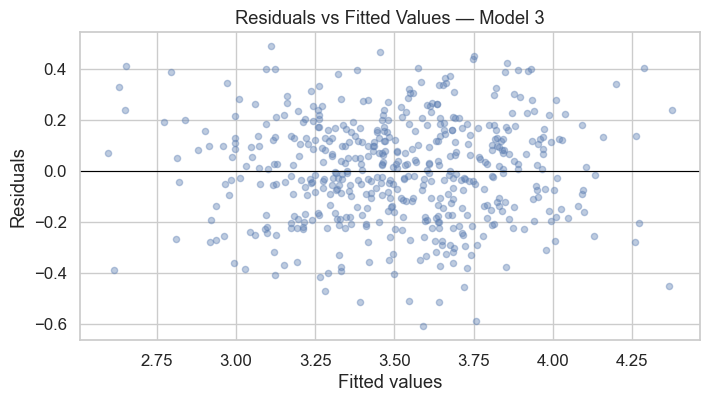

In [8]:
# Q6 — Residual vs fitted plot
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

ax.scatter(m3.fittedvalues, m3.resid, color="#5B7DB1", alpha=0.4, s=20)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs Fitted Values — Model 3")

fig.savefig(OUTPUT_DIR / "residuals_vs_fitted.png", dpi=150,
            bbox_inches="tight", transparent=True)
plt.show()

# Interpretation:
# A clean plot: residuals scattered symmetrically around zero with no pattern.
# This is consistent with E[ε|X] ≈ 0 (exogeneity) and homoskedasticity.
# A problematic plot would show: a funnel shape (heteroskedasticity),
# a U-shape (misspecified functional form), or a trend (omitted variable).


### Question 7

Write one sentence interpreting the `female` coefficient from Model 3.
Be precise about units, direction, and the appropriate level of caution
about causality.


In [9]:
# Q7 — Interpret the female coefficient
female_coeff = m3.params["female"]
print(f"Female coefficient: {female_coeff:.4f}")
# Sample interpretation:
# Holding education, experience, and industry constant, female workers earn
# approximately {abs(female_coeff)*100:.1f}% {'less' if female_coeff < 0 else 'more'}
# per hour than male workers on average (using the log approximation).
# This is a conditional correlation, not necessarily a causal gender wage gap:
# unmeasured differences in occupation, hours worked, or firm type
# could partly explain this estimate.
print(f"Female workers earn ~{abs(female_coeff)*100:.1f}% "
      f"{'less' if female_coeff < 0 else 'more'} (conditional on controls).")


Female coefficient: -0.1155
Female workers earn ~11.5% less (conditional on controls).


---
## Part D (Extension): Frisch-Waugh Verification

**Goal.** Verify the Frisch-Waugh-Lovell theorem numerically:
the coefficient on `education` in a multiple regression equals the slope
from regressing the *residualised* outcome on the *residualised* education.


### Question 8

**Residualise.** Run two auxiliary regressions:
1. Regress `log_wage` on `experience + female + C(industry)` → save residuals as `e_y`
2. Regress `education` on `experience + female + C(industry)` → save residuals as `e_x`

Then regress `e_y` on `e_x`. Compare the slope to the education coefficient
from Model 3.


In [10]:
# Q8 — Frisch-Waugh verification
controls = "experience + female + C(industry)"

# Residualise log_wage on controls
e_y = smf.ols(f"log_wage ~ {controls}", data=df).fit().resid

# Residualise education on controls
e_x = smf.ols(f"education ~ {controls}", data=df).fit().resid

# FWL regression
fw = smf.ols("e_y ~ e_x",
             data=pd.DataFrame({"e_y": e_y, "e_x": e_x})).fit()

print(f"FWL slope on e_x:           {fw.params['e_x']:.6f}")
print(f"M3 education coefficient:   {m3.params['education']:.6f}")
print(f"Difference:                 {abs(fw.params['e_x'] - m3.params['education']):.2e}")
# Should be < 1e-10 (numerical precision only)


FWL slope on e_x:           0.082725
M3 education coefficient:   0.082725
Difference:                 1.25e-16
